In [0]:
import mlflow

print("MLflow version:", mlflow.__version__)
print("Current URI:", mlflow.get_tracking_uri())

MLflow version: 3.8.1
Current URI: databricks


In [0]:
mlflow.set_tracking_uri("databricks")

EXPERIMENT_NAME = "/Shared/Football_MLflow_Experiment"

experiment = mlflow.set_experiment(
    EXPERIMENT_NAME
)

print("Experiment:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

Experiment: /Shared/Football_MLflow_Experiment
Experiment ID: 3335466781353570


In [0]:
with mlflow.start_run(
    run_name="MLflow_Connection_Test"
) as run:

    mlflow.log_param(
        "status",
        "connected"
    )

    mlflow.log_metric(
        "connection_score",
        1.0
    )

    print("Run ID:", run.info.run_id)

Run ID: 7d68eb0b6e3d4f908460d40d173abd15


In [0]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("databricks")

EXPERIMENT_NAME = "/Shared/Football_MLflow_Experiment"

try:
    experiment = mlflow.set_experiment(
        EXPERIMENT_NAME
    )

except Exception:
    EXPERIMENT_NAME = (
        "/Users/pranavsnair2004@gmail.com/"
        "Football_MLflow_Experiment"
    )

    experiment = mlflow.set_experiment(
        EXPERIMENT_NAME
    )

print("MLflow connected successfully.")
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Artifact location:", experiment.artifact_location)

MLflow connected successfully.
Tracking URI: databricks
Experiment name: /Shared/Football_MLflow_Experiment
Experiment ID: 3335466781353570
Artifact location: dbfs:/databricks/mlflow-tracking/3335466781353570


In [0]:
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow
import mlflow.sklearn

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

from mlflow.models import infer_signature

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [0]:
EXPERIMENT_NAME = "/Shared/Football_MLflow_Experiment"

mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks-uc")
mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("MLflow registry URI:", mlflow.get_registry_uri())
print("Experiment:", EXPERIMENT_NAME)

MLflow tracking URI: databricks
MLflow registry URI: databricks-uc
Experiment: /Shared/Football_MLflow_Experiment


In [0]:
DATA_DIRECTORY = "/Volumes/workspace/default/football_data"

TRAIN_PATH = f"{DATA_DIRECTORY}/football_train.csv"
TEST_PATH = f"{DATA_DIRECTORY}/football_test.csv"

CHAMPION_INFO_PATH = (
    f"{DATA_DIRECTORY}/champion_run_info.csv"
)

REMOVED_COLUMNS_PATH = (
    f"{DATA_DIRECTORY}/champion_removed_columns.json"
)

TARGET_COLUMN = "match_result"
PRIMARY_METRIC = "test_f1_macro"

RANDOM_STATE = 42

os.makedirs(DATA_DIRECTORY, exist_ok=True)

print("Configuration completed.")

Configuration completed.


In [0]:
OLD_CHAMPION_BACKUP_PATH = (
    f"{DATA_DIRECTORY}/"
    "previous_logistic_regression_champion_info.csv"
)

if os.path.exists(CHAMPION_INFO_PATH):

    previous_champion_df = pd.read_csv(
        CHAMPION_INFO_PATH
    )

    previous_champion_df.to_csv(
        OLD_CHAMPION_BACKUP_PATH,
        index=False
    )

    print(
        "Previous Champion information backed up to:"
    )
    print(OLD_CHAMPION_BACKUP_PATH)

else:
    print(
        "No previous champion_run_info.csv file found."
    )

Previous Champion information backed up to:
/Volumes/workspace/default/football_data/previous_logistic_regression_champion_info.csv


In [0]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

Training shape: (15999, 58)
Testing shape: (4000, 58)

Training rows: 15999
Testing rows: 4000


In [0]:
assert TARGET_COLUMN in train_df.columns, (
    f"{TARGET_COLUMN} is missing from the training data."
)

assert TARGET_COLUMN in test_df.columns, (
    f"{TARGET_COLUMN} is missing from the testing data."
)

assert list(train_df.columns) == list(test_df.columns), (
    "Training and testing columns are different."
)

assert len(train_df) == 15999, (
    f"Expected 15999 training rows, "
    f"but found {len(train_df)}."
)

assert len(test_df) == 4000, (
    f"Expected 4000 testing rows, "
    f"but found {len(test_df)}."
)

print("Dataset validation completed successfully.")

Dataset validation completed successfully.


In [0]:
print("Training target counts:")

print(
    train_df[TARGET_COLUMN].value_counts()
)

print("\nTraining target proportions:")

print(
    train_df[TARGET_COLUMN]
    .value_counts(normalize=True)
    .round(4)
)

Training target counts:
match_result
Home Win    7254
Away Win    4894
Draw        3851
Name: count, dtype: int64

Training target proportions:
match_result
Home Win    0.4534
Away Win    0.3059
Draw        0.2407
Name: proportion, dtype: float64


In [0]:
LEAKAGE_COLUMNS = [
    "home_score",
    "away_score"
]

available_leakage_columns = [
    column
    for column in LEAKAGE_COLUMNS
    if column in train_df.columns
]

train_df = train_df.drop(
    columns=available_leakage_columns,
    errors="ignore"
)

test_df = test_df.drop(
    columns=available_leakage_columns,
    errors="ignore"
)

print(
    "Leakage columns removed:",
    available_leakage_columns
)

Leakage columns removed: []


In [0]:
X_train = train_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_train = train_df[
    TARGET_COLUMN
].copy()

X_test = test_df.drop(
    columns=[TARGET_COLUMN]
).copy()

y_test = test_df[
    TARGET_COLUMN
].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15999, 57)
X_test shape: (4000, 57)
y_train shape: (15999,)
y_test shape: (4000,)


In [0]:
missing_ratios = X_train.isnull().mean()

columns_to_remove = missing_ratios[
    missing_ratios >= 0.95
].index.tolist()

X_train = X_train.drop(
    columns=columns_to_remove,
    errors="ignore"
)

X_test = X_test.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print(
    "Columns removed because of excessive missing values:"
)

print(columns_to_remove)

print(
    "\nRemaining number of features:",
    X_train.shape[1]
)

Columns removed because of excessive missing values:
['season_year', 'Interceptions_Home', 'Interceptions_Host', 'Clearances_Completed_Home', 'Clearances_Completed_Host', 'Pass_Success_per_Home', 'Pass_Success_per_Host', 'Crosses_Completed_Home', 'Crosses_Completed_Host', 'Distance_Covered_(km)_Home', 'Distance_Covered_(km)_Host', 'capacity', 'attendance']

Remaining number of features: 44


In [0]:
with open(
    REMOVED_COLUMNS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        columns_to_remove,
        file,
        indent=4
    )

print(
    "Removed-column information saved to:"
)

print(REMOVED_COLUMNS_PATH)

Removed-column information saved to:
/Volumes/workspace/default/football_data/champion_removed_columns.json


In [0]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical feature names:")
print(categorical_features)

Numeric features: 38
Categorical features: 6

Categorical feature names:
['Country', 'League', 'home_team', 'away_team', 'referee', 'venue']


In [0]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

print("Numeric preprocessing pipeline created.")

Numeric preprocessing pipeline created.


In [0]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Categorical preprocessing pipeline created.")

Categorical preprocessing pipeline created.


In [0]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Combined preprocessor created successfully.")

Combined preprocessor created successfully.


In [0]:
champion_classifier = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

print("Baseline classifier:")
print(champion_classifier)

Baseline classifier:
DecisionTreeClassifier(class_weight='balanced', max_depth=3,
                       min_samples_leaf=10, min_samples_split=20,
                       random_state=42)


In [0]:
champion_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            champion_classifier
        )
    ]
)

print("Champion pipeline created successfully.")

Champion pipeline created successfully.


In [0]:
training_start_time = time.time()

champion_pipeline.fit(
    X_train,
    y_train
)

training_time_seconds = (
    time.time() - training_start_time
)

print("Decision Tree Champion trained successfully.")

print(
    "Training rows used:",
    len(X_train)
)

print(
    "Training time:",
    round(training_time_seconds, 2),
    "seconds"
)

Decision Tree Champion trained successfully.
Training rows used: 15999
Training time: 0.33 seconds


In [0]:
champion_predictions = (
    champion_pipeline.predict(
        X_test
    )
)

champion_probabilities = (
    champion_pipeline.predict_proba(
        X_test
    )
)

print(
    "Number of predictions:",
    len(champion_predictions)
)

print(
    "Probability matrix shape:",
    champion_probabilities.shape
)

Number of predictions: 4000
Probability matrix shape: (4000, 3)


In [0]:
def calculate_metrics(
    y_true,
    y_pred
):
    return {
        "test_accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "test_precision_macro": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_recall_macro": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_macro": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),
        "test_f1_weighted": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0
        )
    }

In [0]:
champion_metrics = calculate_metrics(
    y_test,
    champion_predictions
)

print("=" * 60)
print("BASELINE DECISION TREE CHAMPION RESULTS")
print("=" * 60)

for metric_name, metric_value in (
    champion_metrics.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.4f}"
    )

BASELINE DECISION TREE CHAMPION RESULTS
test_accuracy: 0.3558
test_precision_macro: 0.5227
test_recall_macro: 0.4250
test_f1_macro: 0.3407
test_f1_weighted: 0.3219


In [0]:
print(
    classification_report(
        y_test,
        champion_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Away Win       0.57      0.27      0.37      1223
        Draw       0.27      0.86      0.41       963
    Home Win       0.73      0.15      0.24      1814

    accuracy                           0.36      4000
   macro avg       0.52      0.42      0.34      4000
weighted avg       0.57      0.36      0.32      4000



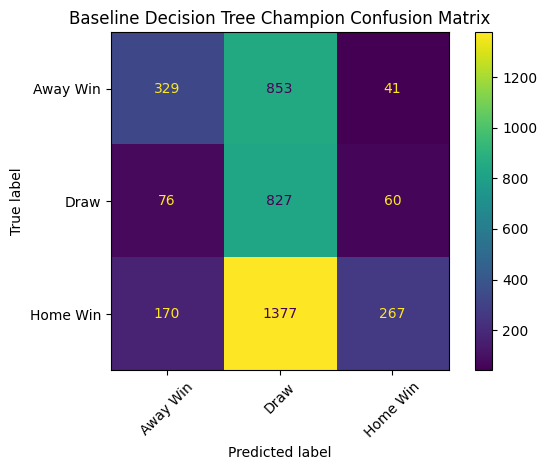

In [0]:
class_labels = sorted(
    y_test.unique().tolist()
)

confusion_values = confusion_matrix(
    y_test,
    champion_predictions,
    labels=class_labels
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_values,
    display_labels=class_labels
)

confusion_display.plot(
    values_format="d"
)

plt.title(
    "Baseline Decision Tree Champion Confusion Matrix"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [0]:
prediction_sample = X_test.head(10).copy()

prediction_sample["actual_result"] = (
    y_test.head(10).values
)

prediction_sample["predicted_result"] = (
    champion_predictions[:10]
)

display(
    prediction_sample[
        [
            "actual_result",
            "predicted_result"
        ]
    ]
)

actual_result,predicted_result
Away Win,Draw
Draw,Draw
Away Win,Draw
Away Win,Draw
Home Win,Draw
Away Win,Draw
Home Win,Away Win
Draw,Draw
Home Win,Home Win
Draw,Draw


In [0]:
signature_input_example = (
    X_test.head(10).copy()
)

signature_output_example = (
    champion_pipeline.predict(
        signature_input_example
    )
)

champion_signature = infer_signature(
    signature_input_example,
    signature_output_example
)

print("MLflow model signature created.")

MLflow model signature created.


In [0]:
with mlflow.start_run(
    run_name="Baseline_DecisionTree_Champion"
) as champion_run:

    champion_run_id = (
        champion_run.info.run_id
    )

    mlflow.log_param(
        "model_role",
        "champion"
    )

    mlflow.log_param(
        "algorithm",
        "DecisionTreeClassifier"
    )

    mlflow.log_param(
        "criterion",
        "gini"
    )

    mlflow.log_param(
        "max_depth",
        3
    )

    mlflow.log_param(
        "min_samples_split",
        20
    )

    mlflow.log_param(
        "min_samples_leaf",
        10
    )

    mlflow.log_param(
        "class_weight",
        "balanced"
    )

    mlflow.log_param(
        "random_state",
        RANDOM_STATE
    )

    mlflow.log_param(
        "training_rows",
        len(X_train)
    )

    mlflow.log_param(
        "testing_rows",
        len(X_test)
    )

    mlflow.log_param(
        "numeric_feature_count",
        len(numeric_features)
    )

    mlflow.log_param(
        "categorical_feature_count",
        len(categorical_features)
    )

    mlflow.log_param(
        "removed_column_count",
        len(columns_to_remove)
    )

    mlflow.log_param(
        "target_column",
        TARGET_COLUMN
    )

    mlflow.log_param(
        "primary_metric",
        PRIMARY_METRIC
    )

    for metric_name, metric_value in (
        champion_metrics.items()
    ):
        mlflow.log_metric(
            metric_name,
            metric_value
        )

    mlflow.log_metric(
        "training_time_seconds",
        training_time_seconds
    )

    mlflow.set_tag(
        "workflow",
        "champion_challenger"
    )

    mlflow.set_tag(
        "model_stage",
        "initial_baseline"
    )

    mlflow.set_tag(
        "version_type",
        "Version 2"
    )

    mlflow.set_tag(
        "registration_status",
        "not_registered_yet"
    )

    logged_champion_model = (
        mlflow.sklearn.log_model(
            sk_model=champion_pipeline,
            artifact_path="model",
            signature=champion_signature,
            input_example=signature_input_example
        )
    )

print("Champion logged successfully.")

print(
    "Run ID:",
    champion_run_id
)

print(
    "Model URI:",
    logged_champion_model.model_uri
)

2026/07/27 14:36:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-f41d3394-c5eb.cloud.databricks.com/ml/experiments/3335466781353570/models/m-a7c158f4672f45faad9513d569e68b0c?o=7474658572124013


Champion logged successfully.
Run ID: 3fa9c04ecf3d4f1597aa3bd68f650d2f
Model URI: models:/m-a7c158f4672f45faad9513d569e68b0c


In [0]:
loaded_champion_model = (
    mlflow.sklearn.load_model(
        logged_champion_model.model_uri
    )
)

verification_predictions = (
    loaded_champion_model.predict(
        X_test.head(20)
    )
)

assert len(verification_predictions) == 20

print(
    "Logged Decision Tree model loaded "
    "successfully."
)

print(
    "Verification predictions:"
)

print(verification_predictions)

Logged Decision Tree model loaded successfully.
Verification predictions:
['Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Away Win' 'Draw' 'Home Win'
 'Draw' 'Home Win' 'Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Draw' 'Away Win'
 'Draw' 'Draw']


In [0]:
original_predictions = (
    champion_pipeline.predict(
        X_test.head(20)
    )
)

assert np.array_equal(
    original_predictions,
    verification_predictions
), (
    "Loaded-model predictions do not match "
    "the original model predictions."
)

print(
    "Loaded-model predictions match the "
    "original predictions."
)

Loaded-model predictions match the original predictions.


In [0]:
champion_information = pd.DataFrame(
    [
        {
            "model_role": "champion",
            "algorithm": (
                "DecisionTreeClassifier"
            ),
            "run_id": champion_run_id,
            "model_uri": (
                logged_champion_model.model_uri
            ),
            "primary_metric": (
                PRIMARY_METRIC
            ),
            "primary_metric_value": (
                champion_metrics[
                    "test_f1_macro"
                ]
            ),
            "test_accuracy": (
                champion_metrics[
                    "test_accuracy"
                ]
            ),
            "test_precision_macro": (
                champion_metrics[
                    "test_precision_macro"
                ]
            ),
            "test_recall_macro": (
                champion_metrics[
                    "test_recall_macro"
                ]
            ),
            "test_f1_macro": (
                champion_metrics[
                    "test_f1_macro"
                ]
            ),
            "test_f1_weighted": (
                champion_metrics[
                    "test_f1_weighted"
                ]
            ),
            "training_rows": len(X_train),
            "testing_rows": len(X_test),
            "training_time_seconds": (
                training_time_seconds
            ),
            "max_depth": 3,
            "min_samples_split": 20,
            "min_samples_leaf": 10,
            "class_weight": "balanced",
            "removed_columns_path": (
                REMOVED_COLUMNS_PATH
            ),
            "registration_status": (
                "pending"
            ),
            "alias_status": "pending"
        }
    ]
)

champion_information.to_csv(
    CHAMPION_INFO_PATH,
    index=False
)

display(champion_information)

print(
    "Champion information saved to:"
)

print(CHAMPION_INFO_PATH)

model_role,algorithm,run_id,model_uri,primary_metric,primary_metric_value,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,training_rows,testing_rows,training_time_seconds,max_depth,min_samples_split,min_samples_leaf,class_weight,removed_columns_path,registration_status,alias_status
champion,DecisionTreeClassifier,3fa9c04ecf3d4f1597aa3bd68f650d2f,models:/m-a7c158f4672f45faad9513d569e68b0c,test_f1_macro,0.34071152404535066,0.35575,0.5227480171428843,0.42499127524655633,0.34071152404535066,0.3219326636027983,15999,4000,0.334583044052124,3,20,10,balanced,/Volumes/workspace/default/football_data/champion_removed_columns.json,pending,pending


Champion information saved to:
/Volumes/workspace/default/football_data/champion_run_info.csv


In [0]:
saved_champion_information = pd.read_csv(
    CHAMPION_INFO_PATH
)

assert len(saved_champion_information) == 1

assert (
    saved_champion_information.iloc[0][
        "algorithm"
    ]
    == "DecisionTreeClassifier"
)

assert (
    saved_champion_information.iloc[0][
        "run_id"
    ]
    == champion_run_id
)

assert (
    saved_champion_information.iloc[0][
        "model_uri"
    ]
    == logged_champion_model.model_uri
)

print(
    "champion_run_info.csv validated "
    "successfully."
)

champion_run_info.csv validated successfully.


In [0]:
print("=" * 70)
print("NOTEBOOK 3 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    "Champion model:",
    "DecisionTreeClassifier"
)

print(
    "Training rows:",
    len(X_train)
)

print(
    "Testing rows:",
    len(X_test)
)

print(
    "Champion accuracy:",
    round(
        champion_metrics[
            "test_accuracy"
        ],
        4
    )
)

print(
    "Champion Macro F1:",
    round(
        champion_metrics[
            "test_f1_macro"
        ],
        4
    )
)

print(
    "Run ID:",
    champion_run_id
)

print(
    "Model URI:",
    logged_champion_model.model_uri
)

print(
    "Saved file:",
    CHAMPION_INFO_PATH
)

NOTEBOOK 3 COMPLETED SUCCESSFULLY
Champion model: DecisionTreeClassifier
Training rows: 15999
Testing rows: 4000
Champion accuracy: 0.3558
Champion Macro F1: 0.3407
Run ID: 3fa9c04ecf3d4f1597aa3bd68f650d2f
Model URI: models:/m-a7c158f4672f45faad9513d569e68b0c
Saved file: /Volumes/workspace/default/football_data/champion_run_info.csv
